# 12 — Structure Rounds Sweep (Sweep E)

Sweeps **Atom–Atom (AA)** and **Atom→Query (AQ)** message-passing round
counts as two *independent* axes — each holding the other, and QQ, at the
original 4/4/4 baseline (not chained through notebook 11 / Sweep D's qq=12
winner). This is deliberate: Phase D and Phase E are one-at-a-time
perturbations off the same shared anchor, so each layer's isolated
contribution is cleanly attributable rather than confounded by whatever the
other axis did. See notebook 11 and this session's discussion for the full
reasoning.

## Sweep design

All runs: EMA + protein-weighted loss, `pearson_weight=0.5`, `agg=multi`,
features off (Sweeps A/B/C winners), features unchanged so no graph rebuild
needed. No `all-max` run in this phase — round counts beyond 4 are tested
one axis at a time, not jointly.

| Sweep axis | Baseline | Tested |
|---|---|---|
| Atom–Atom (AA) | 4 (aq=4, qq=4 held) | 8, 12 |
| Atom→Query (AQ) | 4 (aa=4, qq=4 held) | 8, 12 |

**Baseline**: `phase_a/{attention,distance}_pw05` (aa=4, aq=4, qq=4,
pearson_weight=0.5, agg=multi).

## Conditional combination (not yet run)

If the AA winner, the AQ winner (this notebook), and the QQ winner
(notebook 11 — currently qq=12) are *all* non-baseline, one run per model
combining all three gets queued afterward, to check whether independently-
good changes compound or interfere. See Section 5.

## Key analyses
1. **Marginal gain per round** (Δ Pearson r / Δ rounds) — plateau detector
2. **Training convergence curves** — faster convergence vs. higher endpoint
3. **Per-bin delta + range breakdown** — where along the ESP range each config wins or loses

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))
from src.utils.config import get_data_root

THESIS_ROOT = Path("/home/student/thesis")
DATA_ROOT   = Path(get_data_root())
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"


def show_png_grid(runs, filename, title, ncols=2):
    """Display saved PNG plots from each run's plot_dir in a grid.

    analyze_model.py saves plots with a model-name prefix (e.g.
    'attention_parity_hexbin.png'), so the actual filename is built per-run
    from run['arch'] — passing a bare 'parity_hexbin.png' here is
    deliberate, the prefix is added below.
    """
    def _path(run):
        return run["plot_dir"] / f"{run['arch']}_{filename}"

    available = [r for r in runs if _path(r).exists()]
    if not available:
        print(f"No '*_{filename}' plots found.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, run in zip(axes, available):
        ax.imshow(mpimg.imread(_path(run)))
        ax.set_title(run["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def load_global(ckpt_dir, field):
    p = ckpt_dir / "test_metrics.json"
    if not p.exists():
        return None
    with open(p) as f:
        return json.load(f)["global"].get(field)


def smooth(y, w=5):
    return np.convolve(y, np.ones(w) / w, mode="same")

## 1. Configuration

In [2]:
# Sweep E: AA and AQ varied independently from the 4/4/4 baseline (phase_a pw05).
# qq is held at 4 throughout — not chained through notebook 11's qq=12 winner.
AA_COUNTS   = [8, 12]
AQ_COUNTS   = [8, 12]
ARCHS       = ["attention", "distance"]
ARCH_COLORS = {"attention": "steelblue", "distance": "darkorange"}

ROUND_COLORS = {
    "attention": ["#4393c3", "#08306b"],
    "distance":  ["#d6604d", "#b2182b"],
}

def _baseline_run(arch):
    return dict(label=f"{arch} 4/4/4 (baseline)", arch=arch, sweep="base", rounds=4,
                plot_dir=EVAL_ROOT/"phase_a"/f"{arch}_pw05", ckpt_dir=CKPT_ROOT/"phase_a"/f"{arch}_pw05")

def make_aa_runs(arch, counts):
    return [
        dict(label=f"{arch} aa={n}", arch=arch, sweep="aa", rounds=n,
             plot_dir=EVAL_ROOT/"phase_e"/f"{arch}_aa{n}", ckpt_dir=CKPT_ROOT/"phase_e"/f"{arch}_aa{n}")
        for n in counts
    ]

def make_aq_runs(arch, counts):
    return [
        dict(label=f"{arch} aq={n}", arch=arch, sweep="aq", rounds=n,
             plot_dir=EVAL_ROOT/"phase_e"/f"{arch}_aq{n}", ckpt_dir=CKPT_ROOT/"phase_e"/f"{arch}_aq{n}")
        for n in counts
    ]

AA_RUNS = {a: make_aa_runs(a, AA_COUNTS) for a in ARCHS}
AQ_RUNS = {a: make_aq_runs(a, AQ_COUNTS) for a in ARCHS}
BASELINE_RUNS = [_baseline_run(a) for a in ARCHS]

ALL_RUNS = (
    BASELINE_RUNS
    + AA_RUNS["attention"] + AA_RUNS["distance"]
    + AQ_RUNS["attention"] + AQ_RUNS["distance"]
)

print(f"{'Run':<24}  {'Ckpt':>5}  {'Plots':>5}")
print("-" * 40)
for r in ALL_RUNS:
    has_ckpt  = (r["ckpt_dir"] / "test_metrics.json").exists()
    has_plots = r["plot_dir"].exists()
    print(f"{r['label']:<24}  {'yes' if has_ckpt else 'NO':>5}  {'yes' if has_plots else 'NO':>5}")

Run                        Ckpt  Plots
----------------------------------------
attention 4/4/4 (baseline)    yes    yes
distance 4/4/4 (baseline)    yes    yes
attention aa=8              yes    yes
attention aa=12             yes    yes
distance aa=8               yes    yes
distance aa=12              yes    yes
attention aq=8              yes    yes
attention aq=12             yes    yes
distance aq=8               yes    yes
distance aq=12              yes    yes


## 2. Hexbin + Sorted Predictions

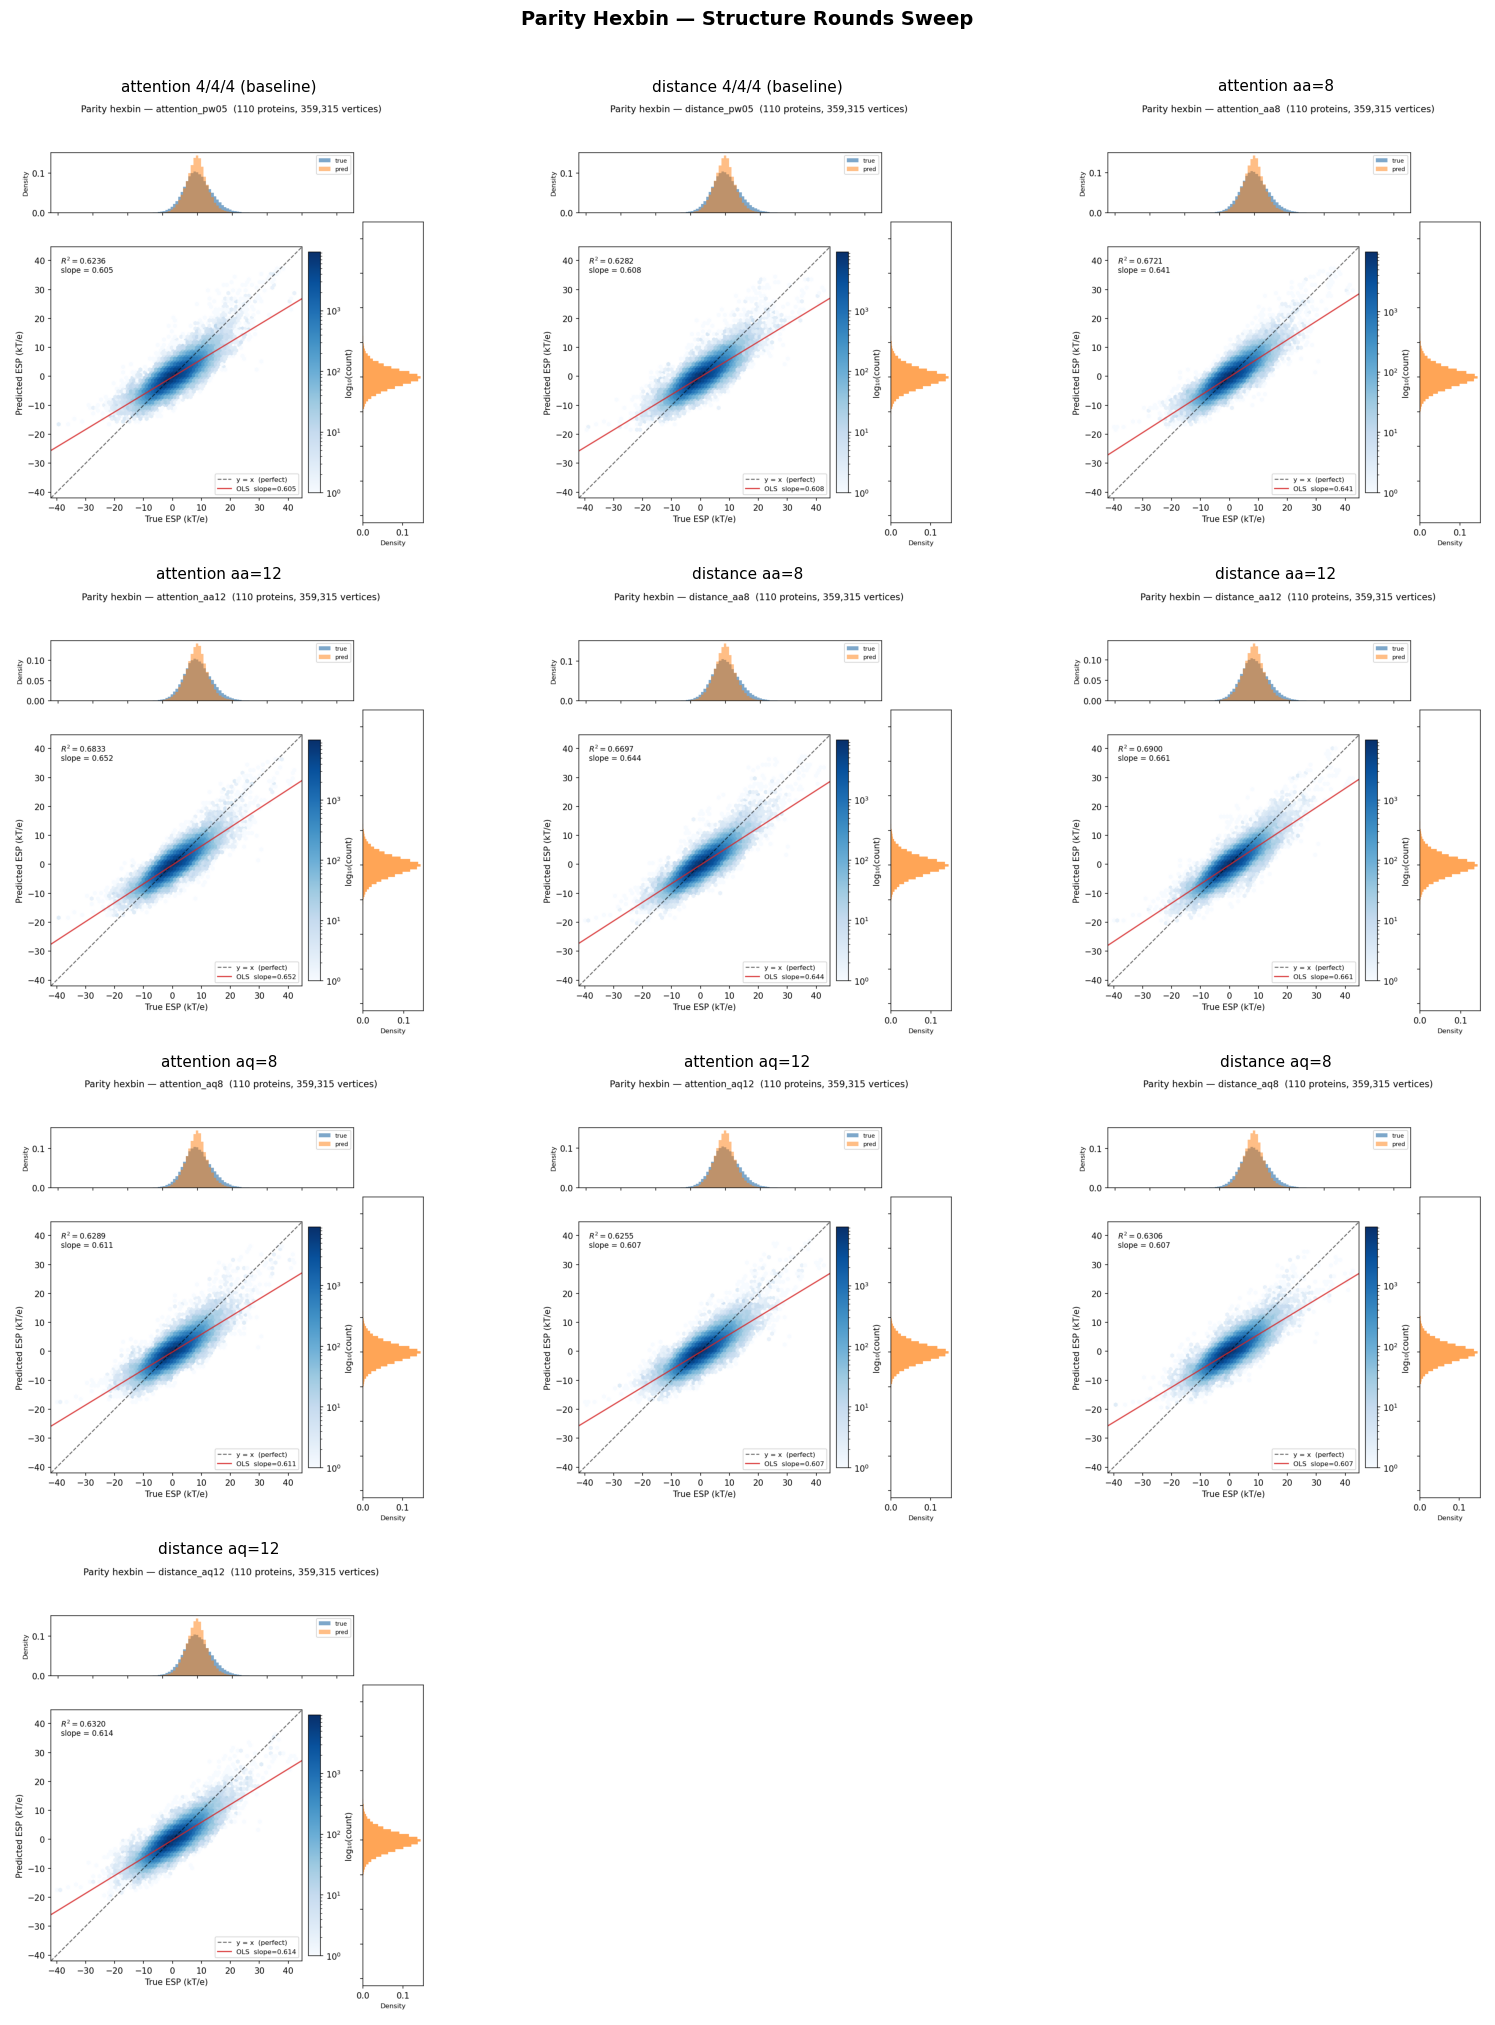

In [3]:
show_png_grid(ALL_RUNS, "parity_hexbin.png", "Parity Hexbin — Structure Rounds Sweep", ncols=3)

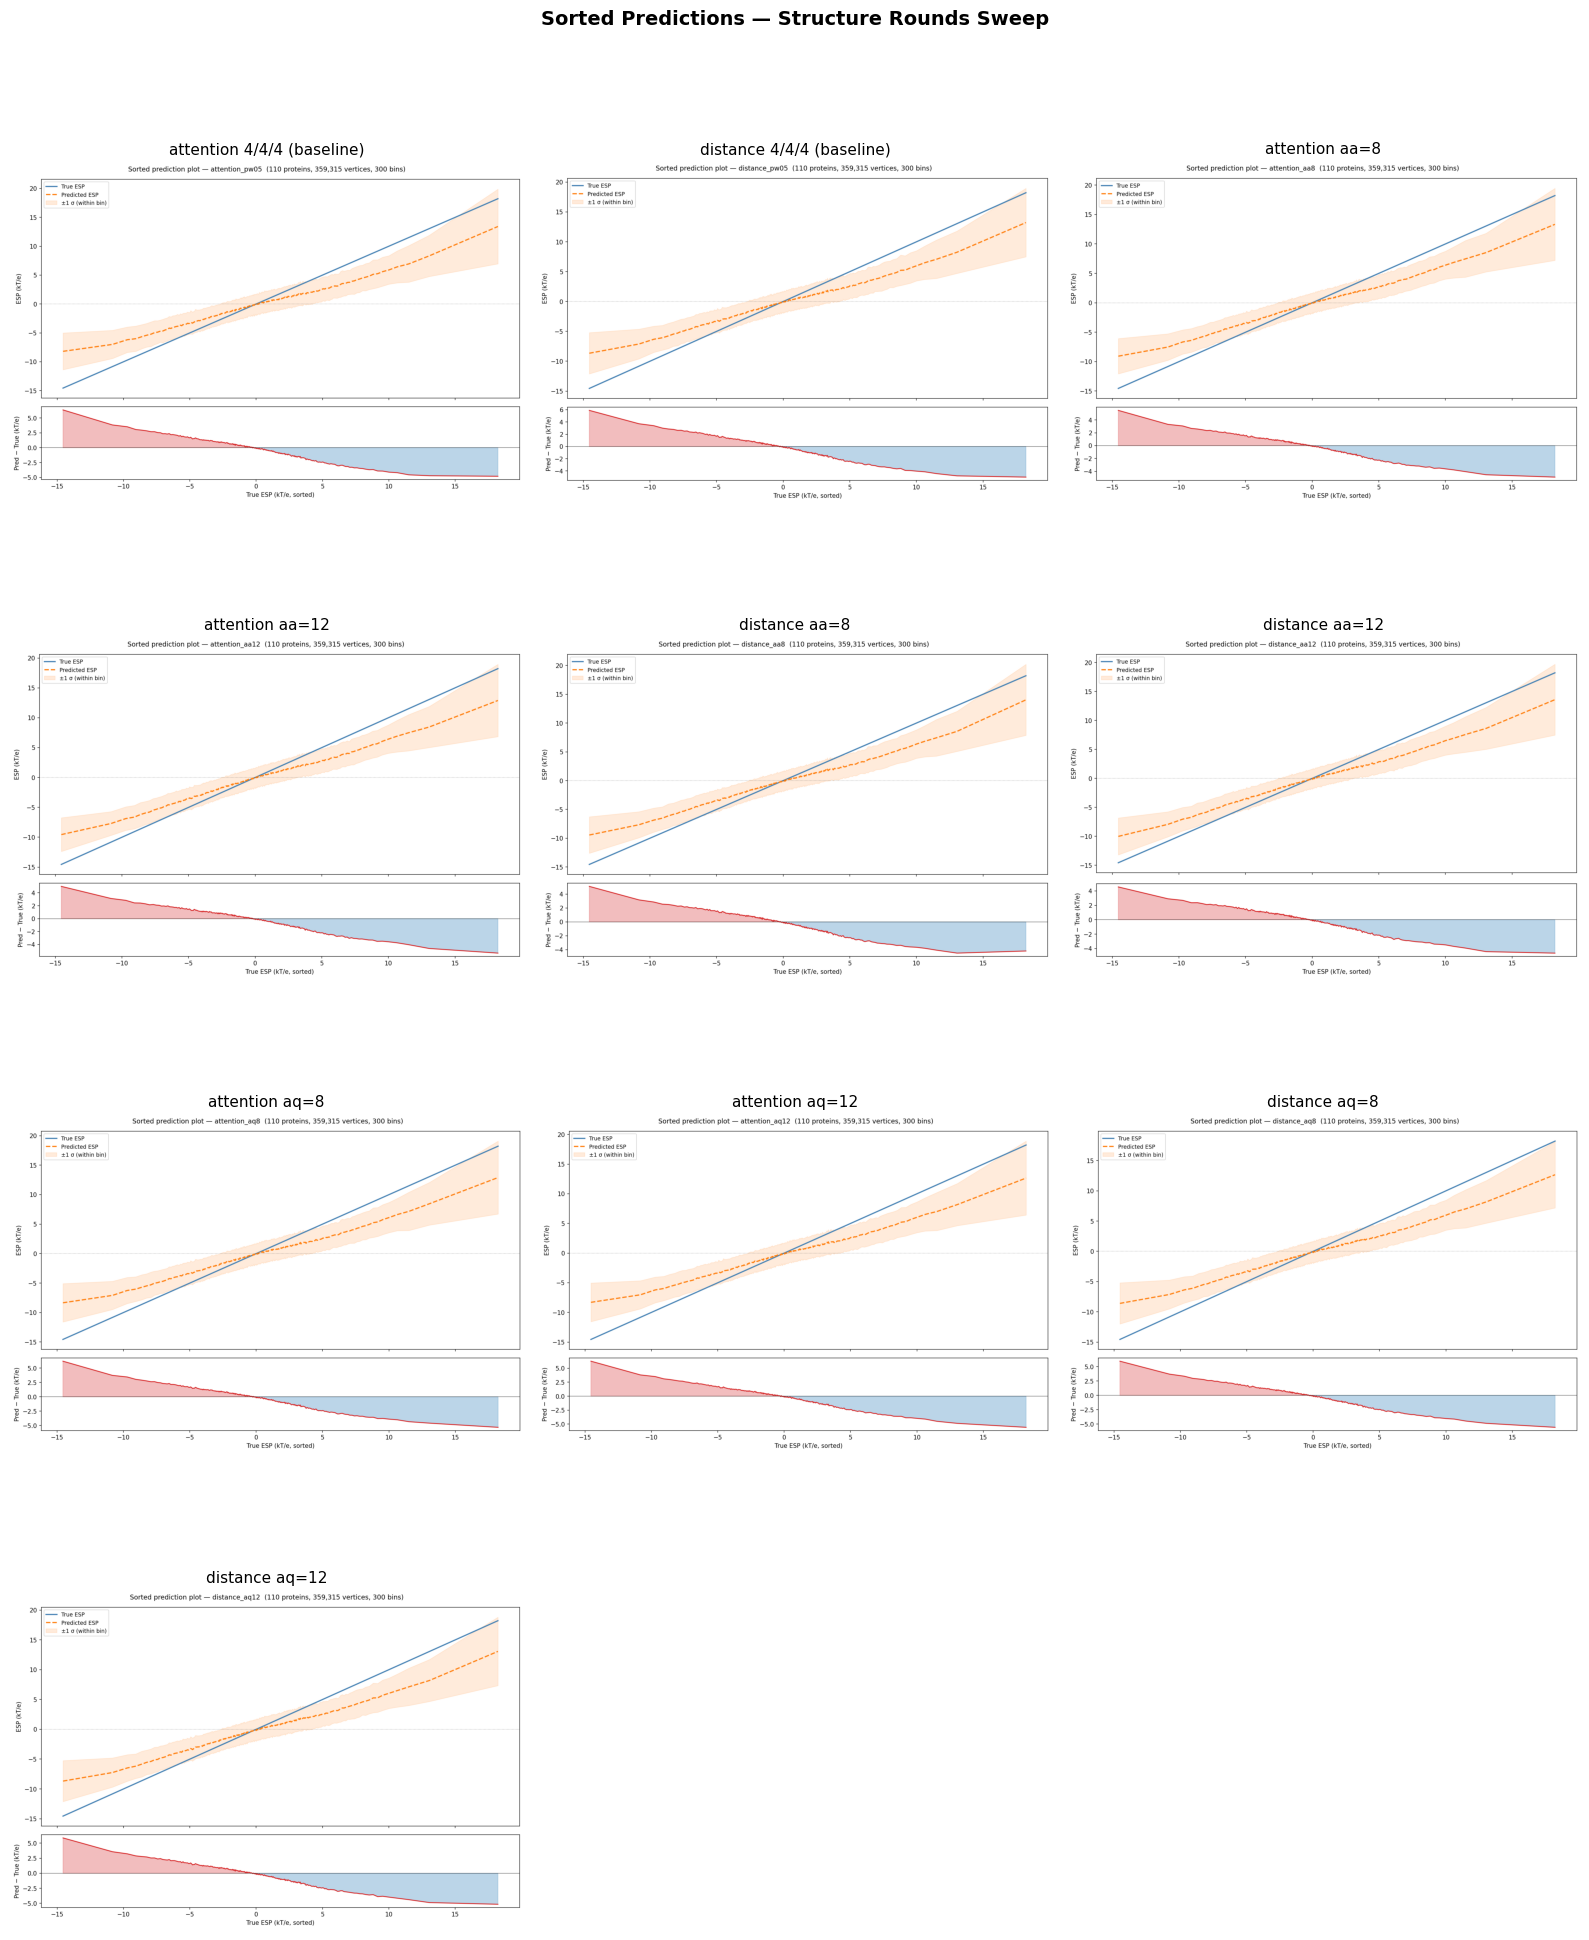

In [4]:
show_png_grid(ALL_RUNS, "sorted_predictions.png", "Sorted Predictions — Structure Rounds Sweep", ncols=3)

## 3. Marginal Gain Per Round — Plateau Detection

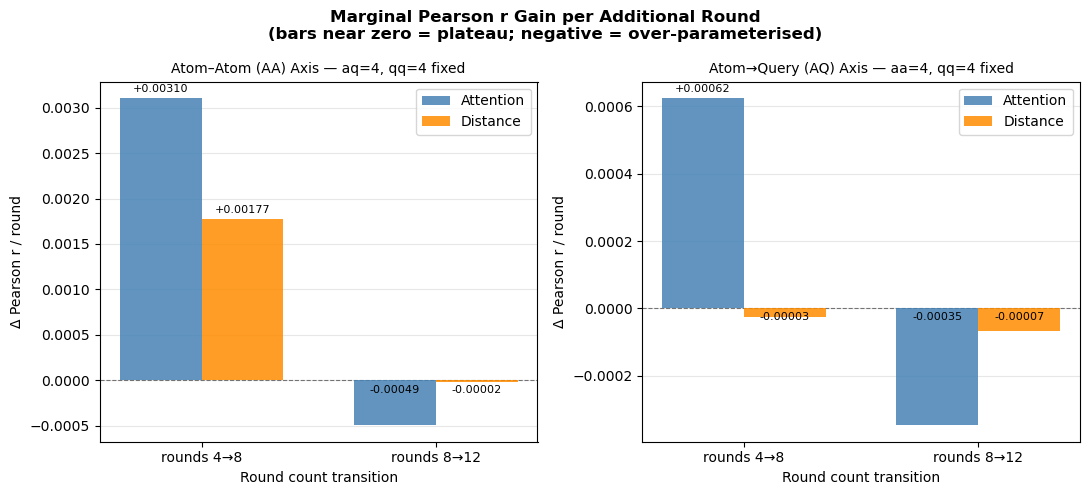

In [5]:
AA_TRANSITIONS = [(4, 8), (8, 12)]
AQ_TRANSITIONS = [(4, 8), (8, 12)]

def _ckpt_for(arch, sweep_runs, n):
    if n == 4:
        return CKPT_ROOT / "phase_a" / f"{arch}_pw05"
    match = [r for r in sweep_runs[arch] if r["rounds"] == n]
    return match[0]["ckpt_dir"] if match else None


def marginal_gains(arch, sweep_runs, transitions):
    labels, gains = [], []
    for lo, hi in transitions:
        ckpt_lo, ckpt_hi = _ckpt_for(arch, sweep_runs, lo), _ckpt_for(arch, sweep_runs, hi)
        if ckpt_lo is None or ckpt_hi is None:
            continue
        r_lo = load_global(ckpt_lo, "pearson_r")
        r_hi = load_global(ckpt_hi, "pearson_r")
        if r_lo is None or r_hi is None:
            continue
        labels.append(f"{lo}→{hi}")
        gains.append((r_hi - r_lo) / (hi - lo))
    return labels, gains


fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle(
    "Marginal Pearson r Gain per Additional Round\n"
    "(bars near zero = plateau; negative = over-parameterised)",
    fontsize=12, fontweight="bold",
)

for ax, (sweep_runs, transitions, axis_title) in zip(axes, [
    (AA_RUNS, AA_TRANSITIONS, "Atom–Atom (AA) Axis — aq=4, qq=4 fixed"),
    (AQ_RUNS, AQ_TRANSITIONS, "Atom→Query (AQ) Axis — aa=4, qq=4 fixed"),
]):
    w = 0.35
    x = np.arange(len(transitions))

    for i, arch in enumerate(ARCHS):
        labels, gains = marginal_gains(arch, sweep_runs, transitions)
        if not gains:
            continue
        offsets = x[:len(gains)] - w / 2 + i * w
        bars = ax.bar(offsets, gains, w, label=arch.capitalize(),
                      color=ARCH_COLORS[arch], zorder=3, alpha=0.85)
        for bar, val in zip(bars, gains):
            ypos = bar.get_height() if val >= 0 else 0
            va   = "bottom" if val >= 0 else "top"
            pad  = 3 if val >= 0 else -3
            ax.annotate(
                "{:+.5f}".format(val),
                xy=(bar.get_x() + bar.get_width() / 2, ypos),
                xytext=(0, pad), textcoords="offset points",
                ha="center", va=va, fontsize=8,
            )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(["rounds {}→{}".format(a, b) for a, b in transitions], fontsize=10)
    ax.set_xlabel("Round count transition")
    ax.set_ylabel("Δ Pearson r / round")
    ax.set_title(axis_title, fontsize=10)
    ax.legend()
    ax.grid(axis="y", alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()

## 4. Training Convergence Curves

Validation Pearson r by epoch for each round-count variant, overlaid per
architecture × sweep axis (AA, AQ, QQ). Thin line = raw val curve; thick
line = 5-epoch moving average; gray dashed = 4/4/4 baseline.

Key questions:
- Do higher round counts converge **faster** (reach the same endpoint
  sooner), or do they reach a **higher final endpoint**?
- If curves converge to the same endpoint regardless of round count, the
  final-epoch metric underestimates the degree of saturation.

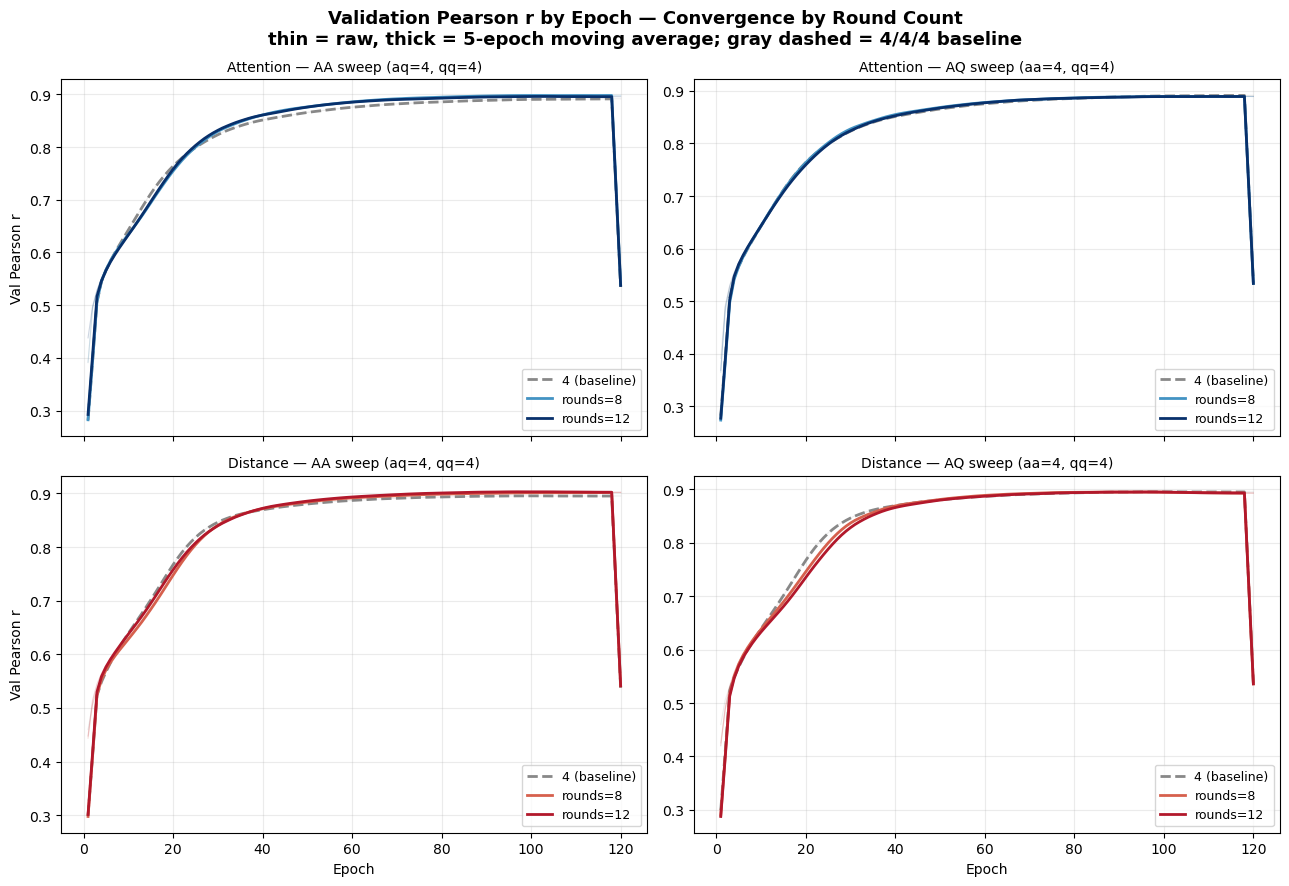

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
fig.suptitle(
    "Validation Pearson r by Epoch — Convergence by Round Count\n"
    "thin = raw, thick = 5-epoch moving average; gray dashed = 4/4/4 baseline",
    fontsize=13, fontweight="bold",
)

SWEEP_ORDER = ["aa", "aq"]
SWEEP_TITLES = {
    "aa": ("Attention — AA sweep (aq=4, qq=4)", "Distance — AA sweep (aq=4, qq=4)"),
    "aq": ("Attention — AQ sweep (aa=4, qq=4)", "Distance — AQ sweep (aa=4, qq=4)"),
}
RUNS_BY_SWEEP = {"aa": AA_RUNS, "aq": AQ_RUNS}

for col, sweep in enumerate(SWEEP_ORDER):
    for row, arch in enumerate(ARCHS):
        ax = axes[row][col]
        palette = ROUND_COLORS[arch]

        base_csv = CKPT_ROOT / "phase_a" / f"{arch}_pw05" / "metrics.csv"
        if base_csv.exists():
            df  = pd.read_csv(base_csv)
            ep  = df["epoch"].values
            val = df["val_pearson_r"].values
            ax.plot(ep, val, color="#888", alpha=0.15, linewidth=0.8)
            ax.plot(ep, smooth(val), color="#888", linewidth=2.0, linestyle="--", label="4 (baseline)")

        for color, run in zip(palette, RUNS_BY_SWEEP[sweep][arch]):
            csv_path = run["ckpt_dir"] / "metrics.csv"
            if not csv_path.exists():
                continue
            df  = pd.read_csv(csv_path)
            ep  = df["epoch"].values
            val = df["val_pearson_r"].values
            ax.plot(ep, val, color=color, alpha=0.20, linewidth=0.8)
            ax.plot(ep, smooth(val), color=color, linewidth=2.0, label=f"rounds={run['rounds']}")

        ax.set_title(SWEEP_TITLES[sweep][row], fontsize=10)
        ax.set_ylabel("Val Pearson r" if col == 0 else "")
        ax.set_xlabel("Epoch" if row == 1 else "")
        ax.legend(fontsize=9, loc="lower right")
        ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 5. Conditional Combination — Preview

Unlike the old v2 sweep's `all-max` (10/10/10) run, this phase doesn't
jointly max every axis — it waits to see which axes actually win in
isolation first. The combination run (1 per model: winning aa, winning aq,
and notebook 11's qq=12) only gets queued if all three axes' winners are
non-baseline. This cell just reports readiness, not results — there's
nothing to combine yet until Sections 3-4 below are fully in.

In [7]:
def _best_nonbaseline(arch, sweep_runs, counts):
    """Return (winning_n, r) among tested non-baseline values, or (4, base_r) if none beat baseline."""
    base_r = load_global(CKPT_ROOT / "phase_a" / f"{arch}_pw05", "pearson_r")
    best_n, best_r = 4, base_r
    for n in counts:
        ckpt = [r for r in sweep_runs[arch] if r["rounds"] == n][0]["ckpt_dir"]
        r = load_global(ckpt, "pearson_r")
        if r is not None and best_r is not None and r > best_r:
            best_n, best_r = n, r
    return best_n, best_r

QQ_WINNER = 12  # from notebook 11 — update if that decision changes

print(f"{'Model':<12}  {'AA winner':>10}  {'AQ winner':>10}  {'QQ winner':>10}  {'Combo needed?':>14}")
print("-" * 62)
for arch in ARCHS:
    aa_n, aa_r = _best_nonbaseline(arch, AA_RUNS, AA_COUNTS)
    aq_n, aq_r = _best_nonbaseline(arch, AQ_RUNS, AQ_COUNTS)
    needed = "yes" if (aa_n != 4 and aq_n != 4 and QQ_WINNER != 4) else "no"
    aa_s = f"{aa_n}" if aa_r is not None else "pending"
    aq_s = f"{aq_n}" if aq_r is not None else "pending"
    print(f"{arch:<12}  {aa_s:>10}  {aq_s:>10}  {QQ_WINNER:>10}  {needed:>14}")

Model          AA winner   AQ winner   QQ winner   Combo needed?
--------------------------------------------------------------
attention              8           8          12             yes
distance               8           4          12              no


## 6. Test Metrics Table

Full test-set results for AA and AQ sweeps. Baseline is `phase_a/{model}_pw05`
(aa=4, aq=4, qq=4, pearson_weight=0.5, agg=multi). QQ results live in
notebook 11, not repeated here.

AA Sweep (aq=4, qq=4 fixed)


,Arch,Rounds,Suffix,Pearson r,RMSE
0,Attention,4,pw05 (baseline),0.889820,2.659808
1,Attention,8,aa8,0.902237,2.416339
2,Attention,12,aa12,0.900258,2.375021
3,Distance,4,pw05 (baseline),0.896363,2.572968
4,Distance,8,aa8,0.903451,2.425063
5,Distance,12,aa12,0.903386,2.349307


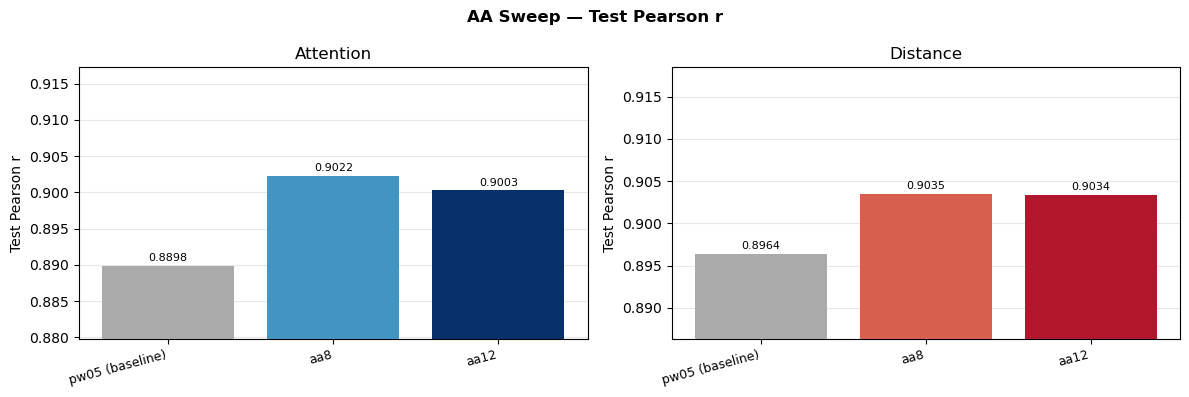

In [8]:
# AA sweep metrics
aa_rows = []
for arch in ARCHS:
    base_ckpt = CKPT_ROOT / "phase_a" / f"{arch}_pw05"
    base_r, base_rmse = load_global(base_ckpt, "pearson_r"), load_global(base_ckpt, "rmse")
    aa_rows.append(dict(Arch=arch.capitalize(), Rounds=4, Suffix="pw05 (baseline)",
                        **({"Pearson r": base_r, "RMSE": base_rmse} if base_r else {})))
    for n in AA_COUNTS:
        ckpt = [r for r in AA_RUNS[arch] if r["rounds"] == n][0]["ckpt_dir"]
        r, rmse = load_global(ckpt, "pearson_r"), load_global(ckpt, "rmse")
        aa_rows.append(dict(Arch=arch.capitalize(), Rounds=n, Suffix=f"aa{n}",
                            **({"Pearson r": r, "RMSE": rmse} if r else {})))

df_aa = pd.DataFrame(aa_rows)
print("AA Sweep (aq=4, qq=4 fixed)")
display(df_aa)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("AA Sweep — Test Pearson r", fontsize=12, fontweight="bold")
for ax, arch in zip(axes, ARCHS):
    sub = df_aa[df_aa["Arch"] == arch.capitalize()].dropna(subset=["Pearson r"])
    colors = ["#aaaaaa"] + ROUND_COLORS[arch][:len(sub) - 1]
    bars = ax.bar(range(len(sub)), sub["Pearson r"], color=colors, zorder=3)
    ax.bar_label(bars, fmt="%.4f", padding=2, fontsize=8)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["Suffix"].tolist(), rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Test Pearson r")
    ax.set_title(arch.capitalize())
    ax.grid(axis="y", alpha=0.3, zorder=0)
    if len(sub) > 0:
        ax.set_ylim(sub["Pearson r"].min() - 0.01, sub["Pearson r"].max() + 0.015)
plt.tight_layout()
plt.show()

AQ Sweep (aa=4, qq=4 fixed)


,Arch,Rounds,Suffix,Pearson r,RMSE
0,Attention,4,pw05 (baseline),0.889820,2.659808
1,Attention,8,aq8,0.892319,2.570870
2,Attention,12,aq12,0.890928,2.582192
3,Distance,4,pw05 (baseline),0.896363,2.572968
4,Distance,8,aq8,0.896259,2.564510
5,Distance,12,aq12,0.895991,2.559578


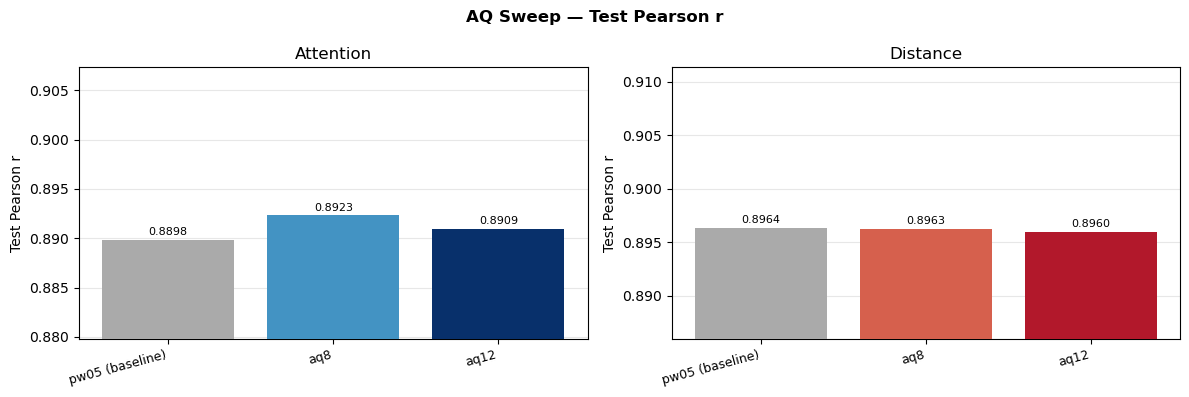

In [9]:
# AQ sweep metrics
aq_rows = []
for arch in ARCHS:
    base_ckpt = CKPT_ROOT / "phase_a" / f"{arch}_pw05"
    base_r, base_rmse = load_global(base_ckpt, "pearson_r"), load_global(base_ckpt, "rmse")
    aq_rows.append(dict(Arch=arch.capitalize(), Rounds=4, Suffix="pw05 (baseline)",
                        **({"Pearson r": base_r, "RMSE": base_rmse} if base_r else {})))
    for n in AQ_COUNTS:
        ckpt = [r for r in AQ_RUNS[arch] if r["rounds"] == n][0]["ckpt_dir"]
        r, rmse = load_global(ckpt, "pearson_r"), load_global(ckpt, "rmse")
        aq_rows.append(dict(Arch=arch.capitalize(), Rounds=n, Suffix=f"aq{n}",
                            **({"Pearson r": r, "RMSE": rmse} if r else {})))

df_aq = pd.DataFrame(aq_rows)
print("AQ Sweep (aa=4, qq=4 fixed)")
display(df_aq)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("AQ Sweep — Test Pearson r", fontsize=12, fontweight="bold")
for ax, arch in zip(axes, ARCHS):
    sub = df_aq[df_aq["Arch"] == arch.capitalize()].dropna(subset=["Pearson r"])
    colors = ["#aaaaaa"] + ROUND_COLORS[arch][:len(sub) - 1]
    bars = ax.bar(range(len(sub)), sub["Pearson r"], color=colors, zorder=3)
    ax.bar_label(bars, fmt="%.4f", padding=2, fontsize=8)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["Suffix"].tolist(), rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Test Pearson r")
    ax.set_title(arch.capitalize())
    ax.grid(axis="y", alpha=0.3, zorder=0)
    if len(sub) > 0:
        ax.set_ylim(sub["Pearson r"].min() - 0.01, sub["Pearson r"].max() + 0.015)
plt.tight_layout()
plt.show()

## 7. Per-Bin Delta vs 4/4/4 Baseline + Range Breakdown

Each run vs the `pw05` baseline. See notebook 07 for why net-vs-baseline can
mislead and the range breakdown (`range_delta_breakdown`,
`src/analysis/model_plots.py`) is checked alongside it, not instead of it.

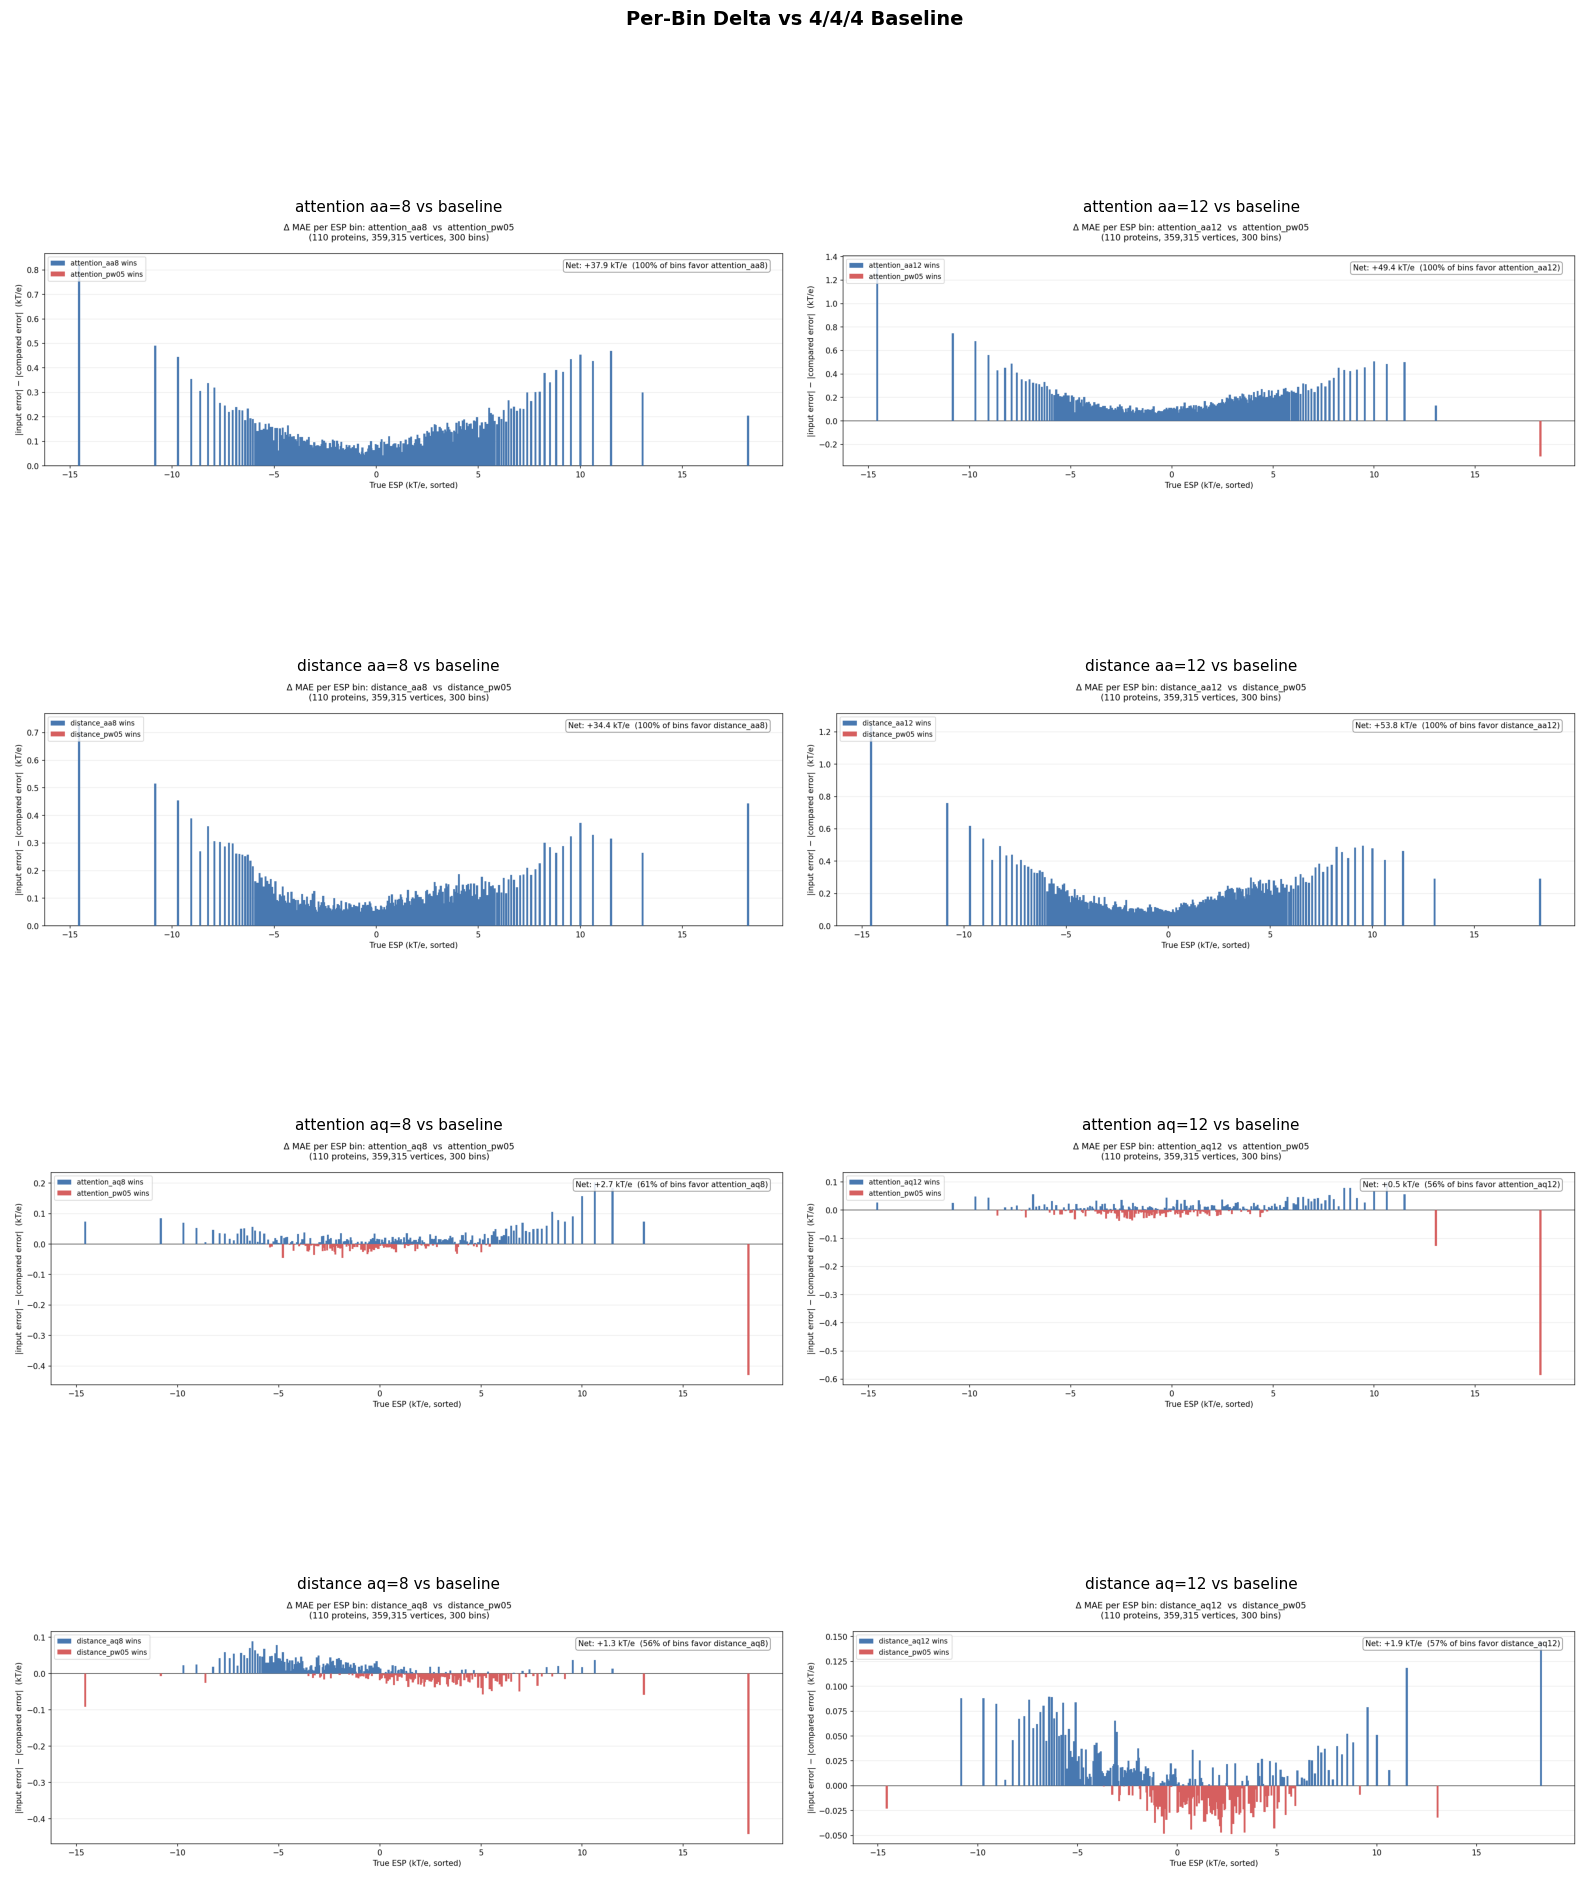


Range breakdown vs baseline, by true-ESP band:


,Comparison,range,n_bins,net_delta_kT_e,mean_delta_kT_e,pct_bins_favor_compared
0,attention aa=8 vs baseline,"[-15, -8)",6,-1.261,-0.210,0.000
1,attention aa=8 vs baseline,"[-8, -2)",86,2.529,0.029,69.767
2,attention aa=8 vs baseline,"[-2, 2)",118,22.252,0.189,100.000
3,attention aa=8 vs baseline,"[2, 8)",79,26.464,0.335,100.000
4,attention aa=8 vs baseline,"[8, 15)",10,5.867,0.587,100.000
5,attention aa=12 vs baseline,"[-15, -8)",6,0.176,0.029,16.667
6,attention aa=12 vs baseline,"[-8, -2)",86,6.105,0.071,86.047
7,attention aa=12 vs baseline,"[-2, 2)",118,25.051,0.212,100.000
8,attention aa=12 vs baseline,"[2, 8)",79,30.367,0.384,100.000
9,attention aa=12 vs baseline,"[8, 15)",10,6.171,0.617,100.000


In [10]:
from src.analysis.model_plots import range_delta_breakdown

def show_image_grid(items, title, ncols=2):
    available = [it for it in items if it["path"].exists()]
    if not available:
        print(f"No images found for '{title}'.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, it in zip(axes, available):
        ax.imshow(mpimg.imread(it["path"]))
        ax.set_title(it["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


delta_items = [
    dict(label=f"{run['label']} vs baseline",
         path=run["plot_dir"] / f"{run['arch']}_delta_vs_{run['arch']}_pw05.png")
    for run in ALL_RUNS if run["sweep"] != "base"
]
show_image_grid(delta_items, "Per-Bin Delta vs 4/4/4 Baseline")

print("\nRange breakdown vs baseline, by true-ESP band:")
frames = []
for run in ALL_RUNS:
    if run["sweep"] == "base":
        continue
    base_ckpt = CKPT_ROOT / "phase_a" / f"{run['arch']}_pw05"
    if not (base_ckpt / "test_predictions").exists() or not (run["ckpt_dir"] / "test_predictions").exists():
        continue
    df = range_delta_breakdown(base_ckpt, run["ckpt_dir"])
    if df is None:
        continue
    df.insert(0, "Comparison", f"{run['label']} vs baseline")
    frames.append(df)

if frames:
    pd.set_option("display.float_format", "{:.3f}".format)
    display(pd.concat(frames, ignore_index=True))
else:
    print("No predictions cached yet.")

## 8. Per-Protein Ranking

Per-protein Pearson r (from `test_metrics.json`) across all runs — which
proteins are universally easy or hard, and which are round-count-sensitive?

In [11]:
pp_data: dict[str, dict[str, float]] = {}

for run in ALL_RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    pp = data.get("per_protein", {})
    pp_data[run["label"]] = {pid: v["pearson_r"] for pid, v in pp.items()}

all_proteins = sorted({pid for d in pp_data.values() for pid in d})
run_labels   = list(pp_data.keys())

pivot = pd.DataFrame(
    {label: [pp_data[label].get(pid, float("nan")) for pid in all_proteins]
     for label in run_labels},
    index=all_proteins,
)

def _short(pid):
    return pid.removeprefix("AF-").removesuffix("-F1")

pivot.index = [_short(p) for p in pivot.index]

pivot["_mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("_mean", ascending=False).drop(columns=["_mean"])

print(f"Loaded per-protein data for {len(pivot)} proteins across {len(run_labels)} runs.")

Loaded per-protein data for 110 proteins across 10 runs.


In [12]:
rank_df = pivot.rank(ascending=False, method="min").astype(int)

rank_df.insert(0, "Mean r",    pivot.mean(axis=1).round(4))
rank_df.insert(1, "Std r",     pivot.std(axis=1).round(4))
rank_df.insert(2, "Mean rank", rank_df.iloc[:, 2:].mean(axis=1).round(2))
rank_df.insert(3, "Rank std",  rank_df.iloc[:, 3:].std(axis=1).round(2))

rank_df = rank_df.sort_values("Mean rank")

print("Top 5 proteins (lowest mean rank = most consistently well-predicted):")
display(rank_df.head(5))

print("\nBottom 5 proteins (highest mean rank = most consistently difficult):")
display(rank_df.tail(5))

print("\nMost round-count-sensitive proteins (highest rank std):")
display(rank_df.sort_values("Rank std", ascending=False).head(5))

Top 5 proteins (lowest mean rank = most consistently well-predicted):


,Mean r,Std r,Mean rank,Rank std,attention 4/4/4 (baseline),distance 4/4/4 (baseline),attention aa=8,attention aa=12,distance aa=8,distance aa=12,attention aq=8,attention aq=12,distance aq=8,distance aq=12
Q8RUD6,0.960,0.005,1.800,1.230,1,1,1,1,2,1,1,2,4,4
Q9GKK3-3,0.957,0.005,3.100,2.080,2,3,3,8,3,5,2,3,1,1
A1SHW4,0.957,0.004,3.200,1.690,5,2,2,5,4,6,3,1,2,2
Q9LUS7,0.949,0.006,6.600,2.840,13,6,5,2,6,7,5,8,6,8
Q8N100,0.949,0.004,8.200,4.180,6,4,11,9,13,16,6,9,5,3



Bottom 5 proteins (highest mean rank = most consistently difficult):


,Mean r,Std r,Mean rank,Rank std,attention 4/4/4 (baseline),distance 4/4/4 (baseline),attention aa=8,attention aa=12,distance aa=8,distance aa=12,attention aq=8,attention aq=12,distance aq=8,distance aq=12
A8WJR8,0.815,0.035,105.000,4.850,110,106,103,95,104,99,107,109,108,109
P0A6Y5,0.816,0.018,105.500,2.320,104,105,106,106,103,105,110,108,102,106
Q07395,0.815,0.020,106.000,1.560,107,108,107,105,105,103,106,105,106,108
A0A0M3KKZ0,0.792,0.040,106.600,4.270,106,109,105,109,109,108,104,96,110,110
G5E8Z2,0.798,0.011,107.500,0.970,108,107,109,107,108,106,109,107,107,107



Most round-count-sensitive proteins (highest rank std):


,Mean r,Std r,Mean rank,Rank std,attention 4/4/4 (baseline),distance 4/4/4 (baseline),attention aa=8,attention aa=12,distance aa=8,distance aa=12,attention aq=8,attention aq=12,distance aq=8,distance aq=12
Q9H5Q4,0.895,0.029,59.600,22.130,99,74,37,39,42,38,87,53,71,56
D4GTA5,0.902,0.015,54.700,20.550,35,39,85,82,57,72,31,36,43,67
P9WKL5,0.850,0.053,87.700,20.300,109,79,108,86,67,52,108,110,80,78
B4T556,0.906,0.021,51.400,20.120,67,63,36,20,74,25,58,77,54,40
Q9LDE1,0.903,0.012,53.300,18.910,41,45,54,74,76,87,40,32,38,46


## 9. Decision

**Status: partial — 3/8 Phase E runs done as of last update** (attention
aa8, aa12, aq8; attention aq12 still training; all 4 distance runs
pending). Numbers below will shift as the rest complete — re-run this
notebook once Phase E finishes.

### What's in so far (attention only)

| Config | Test Pearson r | Test RMSE | vs. baseline |
|---|---|---|---|
| 4/4/4 (baseline) | 0.8926 | 2.589 | — |
| aa=8 | 0.9022 | 2.416 | clear win |
| aa=12 | 0.9003 | 2.375 | clear win, slightly better RMSE than aa=8 despite lower r |
| aq=8 | 0.8923 | 2.571 | essentially a wash — no real gain |
| aq=12 | *pending* | *pending* | — |

**Early read:** AA rounds look like a genuine second lever (not as strong as
QQ, but real) — both aa=8 and aa=12 clearly beat baseline. AQ rounds look
close to redundant at aq=8 (matches the old pre-EMA finding that AQ is
close to saturated even at the default). Whether aq=12 changes this
picture is still open.

### Reading guide (unchanged from the original design)

**Section 3 (Marginal Gain)** is the primary evidence for plateau detection
— compare the `4→8` bar to the `8→12` bar per axis.

**Section 4 (Convergence Curves)** disambiguates: do higher round counts
reach a *higher endpoint*, or just get there *faster*? If curves converge
to the same endpoint regardless of round count, prefer the smaller config.

**Section 5 (Conditional Combination)** — only fires once AA, AQ, and QQ
(notebook 11) all have confirmed non-baseline winners. Currently blocked on
AQ (pending aq=12) and the full distance side.

### Decision

*To be filled in once all 8 runs complete and the range breakdown
(Section 7) confirms the win isn't concentrated in one part of the ESP
range — same check that caught the pearson-weight and aggregation sweeps'
misleading net-vs-baseline numbers earlier in this project.*